In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from iminuit import Minuit
import seaborn as sns
import matplotlib.patches as patches

In [33]:
def setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150):
    """
    Global plotting setup:
    - Seaborn grey background
    - Custom reversed/de-saturated deep palette
    - Serif + STIX math fonts
    - Grid, linewidths, ticks, figure defaults
    """

    # --- Base style (grey background preserved) ---
    plt.style.use("seaborn-v0_8")
    sns.set()
    sns.set_context("paper", font_scale=1.4)
    sns.set_style("ticks")

    # --- Color palette ---
    #colors = sns.color_palette("deep", 10, desat=0.8)
    #colors = sns.color_palette("husl", 10)
    #colors = sns.color_palette("tab10", 10)
    colors = sns.color_palette("Set1", 10)
    #colors = colors[::-1]
    #colors.pop(2)
    sns.set_palette(colors)

    # --- Fonts ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"] + plt.rcParams["font.serif"],
        "mathtext.fontset": "stix",
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    return colors


def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
    
    colors = setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150)

In [34]:
data1 = np.genfromtxt('MLE_Variance_data.txt')
data2 = np.genfromtxt('MLE_Variance_data_2.txt')

def func(x,a, b):
    return 1 + a*x + b*x**2
def ln_likelihood(vals, func, a, b):
    pdf_vals = func(vals,a,b)
    return -np.sum(np.log(pdf_vals))

def normalized_function(x,a,b):
    integral, _ = integrate.quad(lambda x: func(x, a, b), -1, 1)
    return func(x, a, b) / integral 

In [35]:
data1_col1 = data1[:, 0]
data1_col2 = data1[:, 1]
data2_col1 = data2[:, 0]
data2_col2 = data2[:, 1]
data1 = np.append(data1_col1, data1_col2)
data2 = np.append(data2_col1, data2_col2)

print(len(data1))
print(len(data2))

4000
40000


In [36]:
m1 = Minuit(lambda a,b: ln_likelihood(data1, normalized_function, a, b), a=0, b=0)
m1.migrad()

m2 = Minuit(lambda a,b: ln_likelihood(data2, normalized_function, a, b), a=0, b=0)
m2.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.712e+04                  │              Nfcn = 49               │
│ EDM = 1.36e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.226   │   0.016   │            │            │         │         │       │
│ 1 │ b    │   0.583   │   0.035   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 0.000249  0.13e-3 │
│ b │  0.13e-3   0.0012 │
└───┴───────────────────┘

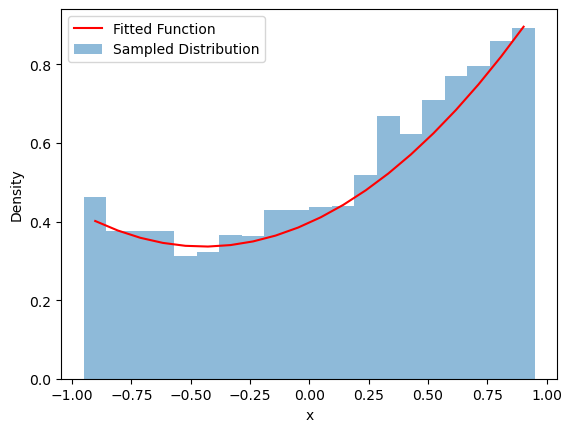

In [37]:
Nbins= 20
x_range = (-0.95, 0.95)
counts, edges = np.histogram(data1, bins=Nbins, range=x_range, density=True)
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.bar(bin_centers, counts, width=edges[1] - edges[0], alpha=0.5, label='Sampled Distribution')
plt.plot(bin_centers, normalized_function(bin_centers, m1.values['a'], m1.values['b']), label='Fitted Function', color='red')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

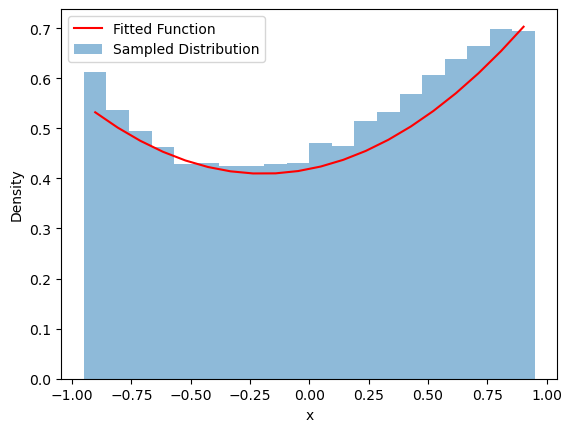

In [38]:
Nbins= 20
x_range = (-0.95, 0.95)
counts, edges = np.histogram(data2, bins=Nbins, range=x_range, density=True)
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.bar(bin_centers, counts, width=edges[1] - edges[0], alpha=0.5, label='Sampled Distribution')
plt.plot(bin_centers, normalized_function(bin_centers, m2.values['a'], m2.values['b']), label='Fitted Function', color='red')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

In [40]:
N = 500 #create 500 datasets
N_points = len(data1) # number of points in each dataset
simulated_datasets_1 = []
for _ in range(N):
    dataset = np.array([])
    while len(dataset) < N_points:
        x = np.random.uniform(-1, 1)
        u = np.random.uniform(0, 1)
        if u < normalized_function(x, m1.values['a'], m1.values['b']):
            dataset = np.append(dataset, x)
    simulated_datasets_1.append(dataset)

In [41]:
N2 = 500 #create 500 datasets
N_points = len(data2) # number of points in each dataset
simulated_datasets_2 = []
for _ in range(N):
    dataset = np.array([])
    while len(dataset) < N_points:
        x = np.random.uniform(-1, 1)
        u = np.random.uniform(0, 1)
        if u < normalized_function(x, m1.values['a'], m1.values['b']):
            dataset = np.append(dataset, x)
    simulated_datasets_2.append(dataset)

In [42]:
a_trials_1 = np.zeros(N)
b_trials_1 = np.zeros(N)
#likelihood = np.zeros(N)
simulated_datasets_1 = np.array(simulated_datasets_1)
for i, dataset in enumerate(simulated_datasets_1):
    m_trial = Minuit(lambda a,b: ln_likelihood(dataset, normalized_function, a, b), a=0, b=0)
    m_trial.migrad()
    a_trials_1[i] = m_trial.values['a']
    b_trials_1[i] = m_trial.values['b']

In [43]:
a_trials_2 = np.zeros(N2)
b_trials_2= np.zeros(N2)
#likelihood = np.zeros(N)
simulated_datasets_2 = np.array(simulated_datasets_2)
for i, dataset in enumerate(simulated_datasets_2):
    m_trial = Minuit(lambda a,b: ln_likelihood(dataset, normalized_function, a, b), a=0, b=0)
    m_trial.migrad()
    a_trials_2[i] = m_trial.values['a']
    b_trials_2[i] = m_trial.values['b']

In [44]:
likelihood_1 = np.zeros(N)
for i, (a, b) in enumerate(zip(a_trials_1, b_trials_1)):
    likelihood_1[i] = ln_likelihood(data1, normalized_function, a, b)
likelihood_2 = np.zeros(N2)
for i, (a, b) in enumerate(zip(a_trials_2, b_trials_2)):
    likelihood_2[i] = ln_likelihood(data2, normalized_function, a, b)

NameError: name 'a_range' is not defined

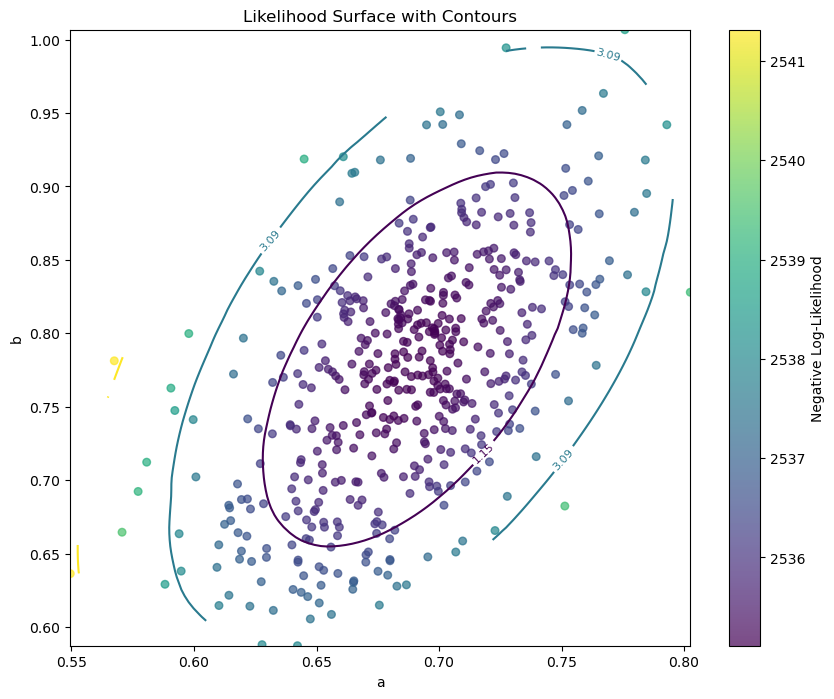

In [ ]:
from scipy.interpolate import griddata

a_trials = np.array(a_trials_1)
b_trials = np.array(b_trials_1)
likelihood = np.array(likelihood_1)
field_1 = likelihood_1 - np.min(likelihood_1)

# Define your regular grid
a_grid = np.linspace(a_trials_1.min(), a_trials_1.max(), 100)
b_grid = np.linspace(b_trials_1.min(), b_trials_1.max(), 100)
A, B = np.meshgrid(a_grid, b_grid)

# Interpolate likelihood onto the grid
Z = griddata((a_trials_1, b_trials_1), field_1, (A, B), method='cubic')

# Now you can use contour
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(a_trials, b_trials, c=likelihood_1, cmap='viridis', alpha=0.7, s=30)
contour = ax.contour(A, B, Z, levels=[1.15,3.09, 5.92], cmap='viridis', linewidths=1.5)
ax.clabel(contour, inline=True, fontsize=8)

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_title('Likelihood Surface with Contours')
plt.colorbar(scatter, label='Negative Log-Likelihood')

ax.grid()
plt.show()